<a href="https://colab.research.google.com/github/manuellazarte/TP-Mineria-Datos-Pinguinos/blob/main/TP1_Lazarte_Larrubia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°1 - Minería de Datos:

> **Año:** 2026  
> **Integrantes:**  
> * Larrubia, Agustín.  
> * Lazarte, Manuel.


## Introducción:
&emsp;El trabajo que se encuentra a continuación tiene como objetivo utilizar los conocimientos adquiridos en las Unidades 2 y 3 de la materia en el dataset 'penguins_size.csv' el cual contiene datos sobre distintas especies de pingüinos.

## Creación de ambiente e importación de dependencias:


In [62]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

# Flujo de datos
from sklearn.pipeline import Pipeline

# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA

import warnings
from scipy.sparse import SparseEfficiencyWarning
warnings.filterwarnings('ignore', message='.*connected components.*')
warnings.filterwarnings('ignore', category=SparseEfficiencyWarning)

## Adquisición y preparación de los datos:

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Lectura :

In [64]:
#file_path = 'penguins_size.csv' #Agus
file_path = '/content/drive/MyDrive/FCEIA/Minería de datos/TPs/TP1/penguins_size.csv' #Manu

df = pd.read_csv(file_path, sep=';')

### Analisis de la estructura de los datos:

&emsp;Realizamos el debido analisis de la estructura y contenido del dataset para ver detalles sobre su información general: cantidad de filas (muestras), nombre y tipo de dato de los atributos, cantidad de valores no nulos.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    object 
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    object 
 6   Unnamed: 6               0 non-null      float64
 7   Unnamed: 7               0 non-null      float64
dtypes: float64(6), object(2)
memory usage: 21.8+ KB


In [66]:
display(df.head())

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Unnamed: 6,Unnamed: 7
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE,NaN,NaN
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE,NaN,NaN
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE,NaN,NaN
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE,NaN,NaN


In [67]:
df.value_counts("Sexo", dropna=False)

,count
Sexo,
MALE,170
FEMALE,166
NaN,10
.,1


### Limpieza de datos:

&emsp;Como se pudo observar en el paso anterior hay dos atributos \(columnas) que no cuentan con nombre y tampoco poseen contenido alguno \(0 non-null) por lo que procedemos a su eliminación, como tambien para todo registro \(fila) que no posea medidas aunque si tenga especificada la especie.

In [68]:
df = df.dropna(axis=1, how='all')
df = df.dropna(subset=df.columns.drop('Especie'), how='all')

print('Duplicados exactos:', df.duplicated().sum())
display(df[df.duplicated(keep=False)])

df['Sexo'] = df['Sexo'].replace('.', np.nan)

df = df.drop_duplicates()

Duplicados exactos: 3


,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
63,Adelie Penguin,41.1,18.2,192.0,4050.0,MALE
126,Adelie Penguin,38.8,17.6,191.0,3275.0,FEMALE
127,Adelie Penguin,38.8,17.6,191.0,3275.0,FEMALE
206,Adelie Penguin,41.1,18.2,192.0,4050.0,MALE
254,Gentoo penguin,59.6,17.0,230.0,6050.0,MALE
256,Gentoo penguin,59.6,17.0,230.0,6050.0,MALE


Se detectaron 3 registros duplicados exactos. Dado que no podemos confirmar que es el mismo animal y que la coincidencia exacta es improbable por azar y probablemente corresponde a un error de carga. Se eliminó la segunda aparición de cada par para no ponderar doble esas observaciones

**Limpieza aplicada**

- Se eliminan las columnas totalmente vacías (`Unnamed`) y las filas sin ninguna medición.
- El valor `'.'` en `Sexo` se trata como faltante.
- Se eliminan los registros duplicados exactos.

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  342 non-null    object 
 1   Longitud Culmen (mm)     342 non-null    float64
 2   Profundidad Culmen (mm)  342 non-null    float64
 3   Longitud Aleta (mm)      342 non-null    float64
 4   Masa corporal (g)        342 non-null    float64
 5   Sexo                     333 non-null    object 
dtypes: float64(4), object(2)
memory usage: 18.7+ KB


### Análisis exploratorio:

#### Observación de outliers

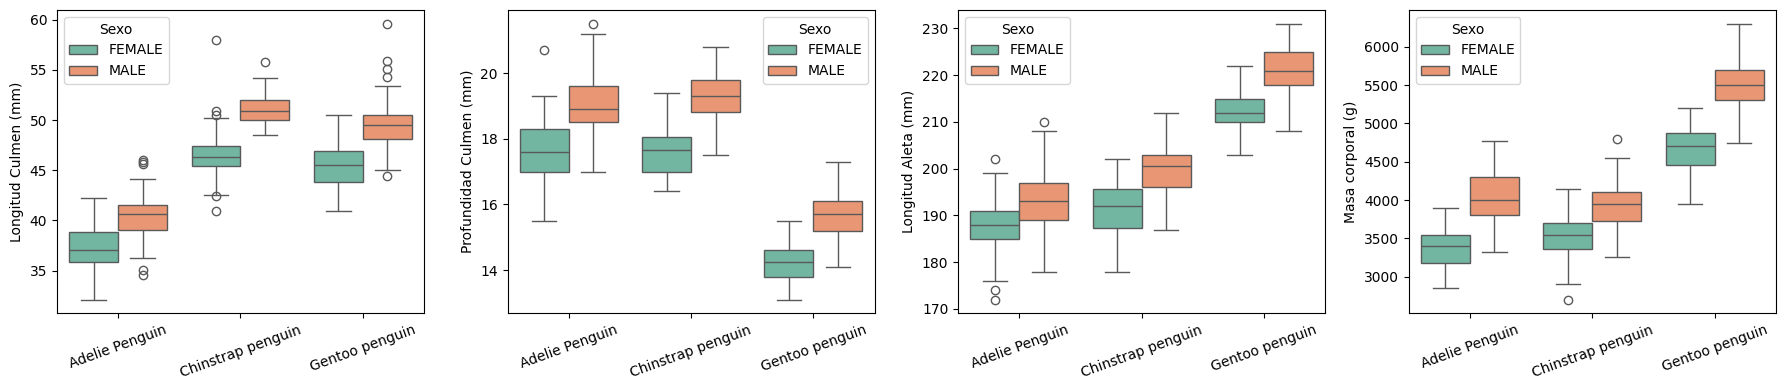

In [70]:
cols = ['Longitud Culmen (mm)', 'Profundidad Culmen (mm)', 'Longitud Aleta (mm)', 'Masa corporal (g)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, df[cols]):
    sns.boxplot(data=df, x='Especie', y=c, hue='Sexo',
                hue_order=['FEMALE', 'MALE'], palette='Set2', ax=ax)
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [71]:
def outliers_extremos(df, variables, k=3.0, grupo=('Especie', 'Sexo')):
    """Filas fuera de [Q1 - k*IQR, Q3 + k*IQR] dentro de cada (especie, sexo)."""
    d = df[df['Sexo'].isin(['FEMALE', 'MALE'])]
    filas = []
    for clave, g in d.groupby(list(grupo)):
        for v in variables:
            q1, q3 = g[v].quantile(.25), g[v].quantile(.75)
            iqr = q3 - q1
            lo, hi = q1 - k * iqr, q3 + k * iqr
            for idx, val in g.loc[(g[v] < lo) | (g[v] > hi), v].items():
                filas.append({'fila': idx, 'Especie': clave[0], 'Sexo': clave[1], 'variable': v,
                              'valor': val, 'límite_inf': round(lo, 1), 'límite_sup': round(hi, 1)})
    return pd.DataFrame(filas)

Decisión sobre outliers. Se eliminaron 2 observaciones extremas (fuera de 3*IQR) calculados dentro de cada especie y sexo.

se retiran por robustez, porque son atípicas respecto de su grupo y estiran los ejes de las proyecciones (por ejemplo, en Isomap). Aunque el efecto sobre el análisis es mínimo: la varianza explicada por las dos primeras componentes de PCA pasa de 0.882 a 0.883.

In [72]:
extremos = outliers_extremos(df, cols)
display(extremos)

df = df.drop(index=extremos['fila'].unique())
print(df.shape)

,fila,Especie,Sexo,variable,valor,límite_inf,límite_sup
0,170,Chinstrap penguin,FEMALE,Longitud Culmen (mm),58.0,39.6,53.2
1,254,Gentoo penguin,MALE,Longitud Culmen (mm),59.6,40.9,57.7


(340, 6)


In [73]:
#excluimos Especie y Sexo
X = df.drop(['Especie', 'Sexo'], axis=1)

#almacenamos para colorear el grafico mas adelante
y_especie = df['Especie']
y_sexo = df['Sexo']

display(X.head())

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


####Observamos la correlación entre atributos:

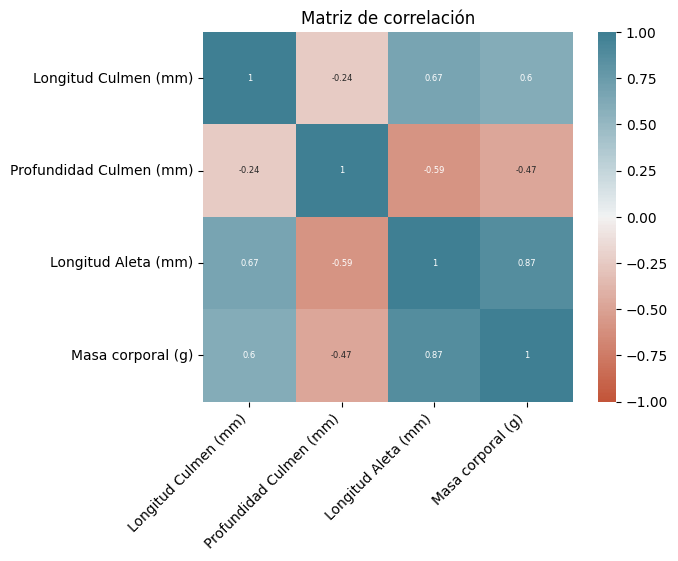

In [74]:
corr = X.corr()
ax = sns.heatmap(corr,vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(20, 220, n=200), square=True, annot = True, annot_kws = {'size': 6})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45,horizontalalignment='right')
plt.title('Matriz de correlación')
plt.show()

&emsp;Se observa una correlación positiva fuerte entre `Longitud Aleta (mm)` y `Masa corporal (g)`, moderada entre `Longitud Culmen (mm)` - `Masa corporal (g)` y `Longitud culmen (mm)` - `Longitud Aleta (mm)`
Al mismo tiempo también se puede ver una correlación negativa moderada entre `Profundidad Culmen (mm)` - `Masa corporal (g)` y `Profundida Culmen (mm)` - `Longitud Aleta (mm)`

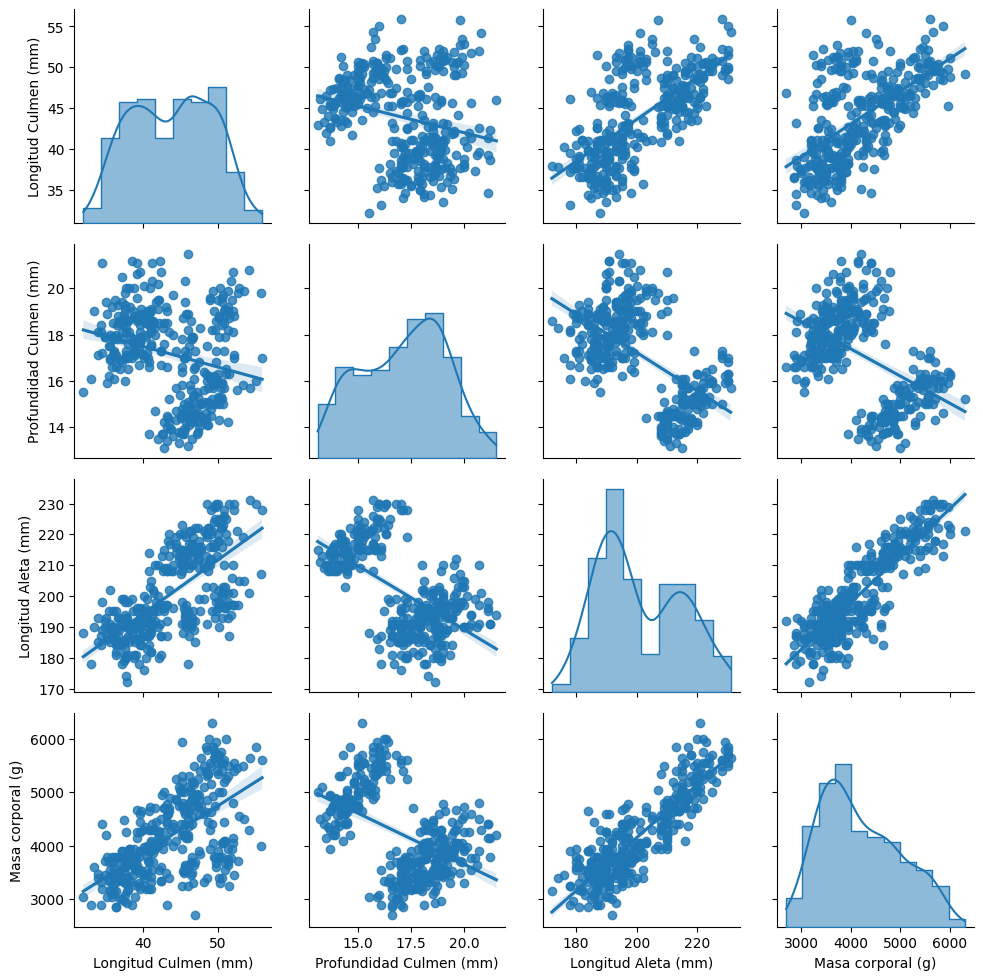

In [75]:
g = sns.PairGrid(X)
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)

&emsp;En los scatterplots se observan relaciones positivas entre Longitud Culmen (mm), Longitud Aleta (mm) y Masa corporal (g), siendo especialmente marcada la relación entre Longitud Aleta (mm) y Masa corporal (g). Por otro lado, Profundidad Culmen (mm) presenta relaciones negativas con las otras tres variables. En varias de estas relaciones se observan agrupamientos diferenciados de los datos, en lugar de una única distribución continua.

&emsp;Así mismo, En la diagonal se observan las distribuciones individuales de las cuatro variables. Longitud Culmen (mm) presenta una distribución relativamente extendida, con cierta concentración de valores en dos zonas. Profundidad Culmen (mm) también muestra dos concentraciones diferenciadas. Longitud Aleta (mm) presenta una bimodalidad marcada, con un grupo de valores alrededor de 185–200 mm y otro cercano a 210–225 mm. Masa corporal (g) presenta asimismo una distribución bimodal, con una concentración en torno a 3000–4000 g y otra en valores superiores.

&emsp;La relacion negativa existente entre Masa corporal (g) y Profundida Culmen (mm) resulta engañosa ya que se pueden observar dos conjuntos diferentes de datos los cuales tienen una relación positiva.

### Normalización:

&emsp;Como se observa en la estructura de arriba tenemos variables que poseen distintas escalas como por ejemplo Longitud Culmen, Profundidad Culmen y Longitud aleta en milimetros contra Masa corporal que esta en gramos y ademas de escalas poseen distinto ordenes de magnitud, por lo que es necesario normalizar estas variables para hacer que todas contribuyan de forma equitativa al análisis, evitando que la Masa Corporal domine los resultados simplemente por tener valores numericos más grandes

In [76]:
scaler = StandardScaler().set_output(transform="pandas")
X_std = scaler.fit_transform(X)
X_std.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,3.400000e+02,3.400000e+02,3.400000e+02,3.400000e+02
mean,1.044916e-15,-1.128509e-15,8.359326e-16,3.343731e-16
std,1.001474e+00,1.001474e+00,1.001474e+00,1.001474e+00
min,-2.194932e+00,-2.048032e+00,-2.070545e+00,-1.880756e+00
25%,-8.668709e-01,-7.963660e-01,-7.804072e-01,-8.134245e-01
50%,7.773615e-02,7.600729e-02,-2.786867e-01,-1.855827e-01
75%,8.586736e-01,7.840204e-01,8.681029e-01,6.933959e-01
max,2.256879e+00,2.200047e+00,2.158241e+00,2.639706e+00


## Reducción de Dimensionalidad:

### PCA:

#### 1. Varianza acumulada

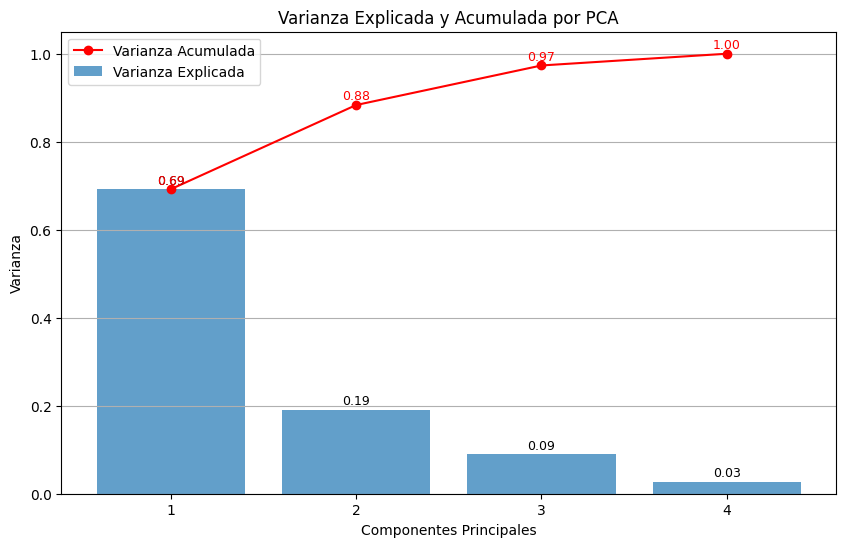

In [77]:
## Definimos pipeline
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()), #scaler a usar con un output de df
    ('pca', PCA().set_output(transform="pandas")) # algoritmo
])

# Aplicamos el pipeline

df_pca = pca_pipeline.fit_transform(X_std)

pca_pipeline.named_steps['pca'].explained_variance_ratio_

df_pca['Especie'] = df['Especie']

# Varianza explicada y acumulada
var_exp = pca_pipeline.named_steps['pca'].explained_variance_ratio_
var_cum = np.cumsum(var_exp)
n_comp = len(var_exp)
# Crear figura
fig, ax = plt.subplots(figsize=(10,6))

# Barras: varianza explicada
bars = ax.bar(range(1, n_comp+1), var_exp, alpha=0.7, label='Varianza Explicada')

# Línea: varianza acumulada
line = ax.plot(range(1, n_comp+1), var_cum, color='red', marker='o', label='Varianza Acumulada')

# Etiquetas sobre las barras
for bar, v in zip(bars, var_exp):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

# Etiquetas sobre los puntos de la línea
for i, v in enumerate(var_cum, start=1):
    ax.text(i, v + 0.005, f"{v:.2f}", color='red', ha='center', va='bottom', fontsize=9)

# Etiquetas y estilo
ax.set_xlabel('Componentes Principales')
ax.set_ylabel('Varianza')
ax.set_title('Varianza Explicada y Acumulada por PCA')
ax.set_xticks(range(1, n_comp+1))
ax.legend()
ax.grid(axis='y')

plt.show()

&emsp;Como podemos observar el criterio 75% a 85% de variancia acumulada con dos componentes ya se cumple por encima de 3%.

&emsp;La mayor parte de la varianza explicada se acumula en los primeros dos componentes, obteniendo un 69% y 19% respectivamente de la varianza.

####2. Kaisser

&emsp;El criterio de Kaisser indica que se deben aceptar los eigenvalues con un valor >= 10% (0.1).

&emsp;Bajo este criterio, solo las dos primeros cumplen con ese criterio.

In [78]:
var_exp

array([0.69195648, 0.19140184, 0.08995669, 0.02668499])

####3. Gráfico del codo

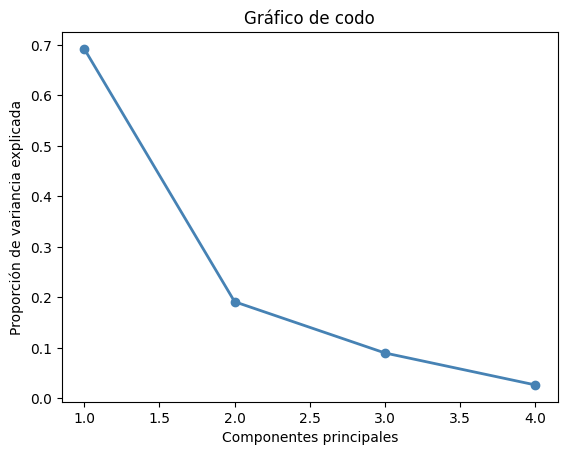

In [79]:
PC_values = np.arange(pca_pipeline.named_steps['pca'].n_components_) + 1
plt.plot(PC_values, pca_pipeline.named_steps['pca'].explained_variance_ratio_, 'o-', linewidth=2, color='steelblue')
plt.title('Gráfico de codo')
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de variancia explicada')
plt.show()

#### Criterio elegido:

&emsp;Elegimos el criterio de varianza acumulada por ser el más interpretable (retiene 88% de la información) y porque permite la visualización en 2D.

####Gráfico PCA:

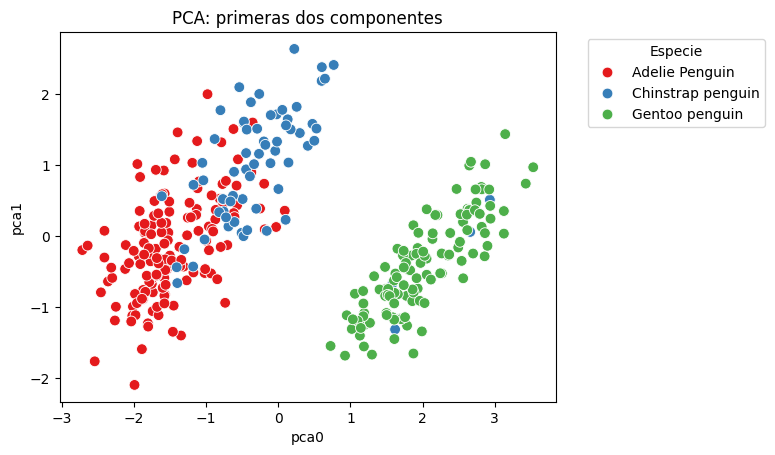

In [80]:
# Visualizamos en scatterplot las primeras dos componentes
sns.scatterplot(
    x=df_pca['pca0'],
    y=df_pca['pca1'],
    hue=df_pca['Especie'],
    palette='Set1',
    s=60
)

plt.xlabel('pca0')
plt.ylabel('pca1')
plt.title('PCA: primeras dos componentes')
plt.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

###Isomap

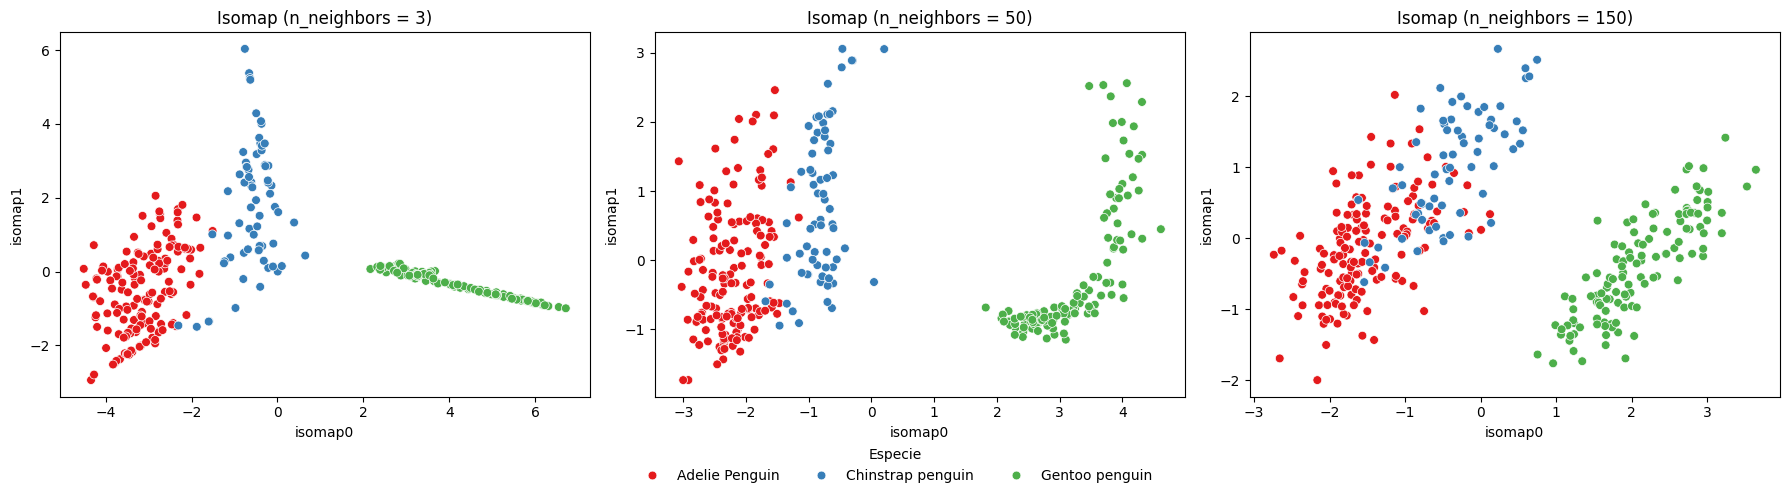

In [86]:
ks = [3, 50, 150]
colores = {'Adelie Penguin': '#E41A1C', 'Chinstrap penguin': '#377EB8', 'Gentoo penguin': '#4DAF4A'}

fig, axes = plt.subplots(1, len(ks), figsize=(6 * len(ks), 5))
for ax, k in zip(axes, ks):
    emb = Isomap(n_neighbors=k, n_components=2).fit_transform(X_std)
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=y_especie.values, hue_order=list(colores),
                    palette=colores, s=40, ax=ax)
    ax.set_title(f'Isomap (n_neighbors = {k})'); ax.set_xlabel('isomap0'); ax.set_ylabel('isomap1')

handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()
fig.legend(handles, labels, title='Especie', loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

* Se observa lo siguiente en la representación

Gentoo pasa de una línea casi recta sin ancho que se desplaza de manera horizontal sobre la figura (k=3 y 6) a una forma de "L" con ancho (k=50), con un tramo horizontal denso y otro vertical más disperso

Chinstrap forma un brazo vertical muy estirado con k=3 (llega a y≈6), menos con k=6 y se acorta bastante con k=50 (y≈3), donde queda como una banda vertical al lado de Adelie

Adelie pasa de una nube dispersa a la izquierda (k=3) a una nube alargada en diagonal (k=6) y a una banda alta (k=50).

Adelie y Chinstrap se distinguen en los tres casos, con una pequeña zona de contacto cerca de x≈-2 a -1. Gentoo queda separada del resto en todos.

Con k=150 los vecinos cruzan entre especies, se forman "atajos" y las distancias geodésicas se parecen a las euclídeas, por lo que se pierde la separación local y el gráfico se asemeja al de PCA.

**Valor más apropiado**. Consideramos k=50 el más apropiado: es aproximadamente el menor k que conecta el grafo, y aun así mantiene separadas a Adelie y Chinstrap, a diferencia de k=150.

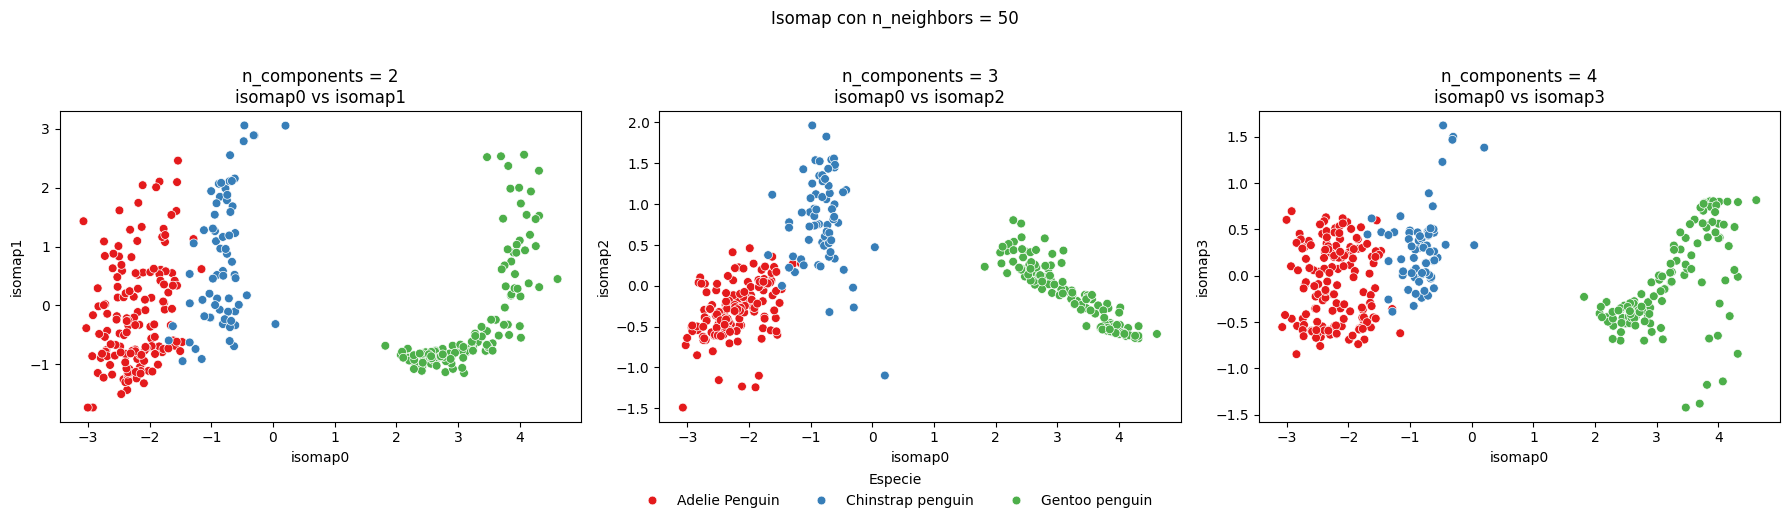

In [85]:
N_VECINOS = 50
componentes = [2, 3, 4]
colores = {'Adelie Penguin': '#E41A1C', 'Chinstrap penguin': '#377EB8', 'Gentoo penguin': '#4DAF4A'}

fig, axes = plt.subplots(1, len(componentes), figsize=(6 * len(componentes), 5))
embs = {}
for ax, c in zip(axes, componentes):
    emb = Isomap(n_neighbors=N_VECINOS, n_components=c).fit_transform(X_std)
    embs[c] = emb
    sns.scatterplot(x=emb[:, 0], y=emb[:, c - 1], hue=y_especie.values, hue_order=list(colores),
                    palette=colores, s=40, ax=ax)
    ax.set_title(f'n_components = {c}\nisomap0 vs isomap{c - 1}')
    ax.set_xlabel('isomap0'); ax.set_ylabel(f'isomap{c - 1}')

handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()
fig.suptitle(f'Isomap con n_neighbors = {N_VECINOS}', y=1.02)
fig.legend(handles, labels, title='Especie', loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

Los primeros ejes del embedding no cambian al aumentar n_components, por lo que el gráfico 2D es el mismo. En el panel de isomap0 vs isomap1, Gentoo se separa claramente de las otras dos especies mientra que Adelie y Chinstrap se distinguen con una zona de contacto.

Al graficar isomap0 contra isomap2, las tres especies siguen reconociéndose pero Adelie y Chinstrap se mezclan más

Con isomap3 la estructura se vuelve difusa y los grupos casi no se separan.

Es decir, el primer eje concentra la separación entre especies y los ejes adicionales aportan poco a lo que se puede visualizar, por lo que se trabaja con 2 componentes.

###t-SNE:

###K-means

In [83]:
# K-means

###Clustering jerárquico

In [84]:
# Clustering jerárquico